<a href="https://colab.research.google.com/github/ProAym/Brain-tumors-Detection/blob/main/Brain_tumor_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install split-folders
import os
import splitfolders
from google.colab import drive

# 1. Mount Google Drive to access your files
drive.mount('/content/drive')

# 2. Define your source and destination paths on Drive
# Path where your original 4 folders (pituitary, meningioma, etc.) are located
input_folder = "/content/drive/MyDrive/brain_tumor_dataset"

# Path where you want the new 'split_data' folder to be created on your Drive
output_folder = "/content/drive/MyDrive/brain_tumor_dataset_split"

# 3. Perform the split directly on Drive
# This will create 'train', 'val', and 'test' folders inside 'brain_tumor_dataset_split'
splitfolders.ratio(input_folder, output=output_folder, seed=1337, ratio=(.7, .15, .15))

# 4. Set your directory variables for the model to use the Drive paths
ROOT_DIR = output_folder
train_path = os.path.join(ROOT_DIR, "train")
val_path = os.path.join(ROOT_DIR, "val")
test_path = os.path.join(ROOT_DIR, "test")

print(f"Dataset split successfully. Files are saved at: {output_folder}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Copying files: 7061 files [04:26, 26.53 files/s]

Dataset split successfully. Files are saved at: /content/drive/MyDrive/brain_tumor_dataset_split


In [ ]:

from tensorflow.keras.layers import Conv2D, MaxPool2D, Dropout, Flatten, Dense, Input
from tensorflow.keras.models import Sequential

model = Sequential([
    Input(shape=(224, 224, 3)),
    Conv2D(filters=16, kernel_size=(3,3), activation='relu'),
    Conv2D(filters=36, kernel_size=(3,3), activation='relu'),
    MaxPool2D(pool_size=(2,2)),

    Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    MaxPool2D(pool_size=(2,2)),

    Conv2D(filters=128, kernel_size=(3,3), activation='relu'),
    MaxPool2D(pool_size=(2,2)),

    Dropout(rate=0.25),
    Flatten(),
    Dense(units=64, activation='relu'),
    Dropout(rate=0.25),
    # Changed to 4 units for 4 classes, and softmax for multi-class probability
    Dense(units=4, activation='softmax')
])

# Use categorical_crossentropy instead of binary
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 36)   │         5,220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 36)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 64)   │        20,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     5,537,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,638,440 (21.51 MB)

 Trainable params: 5,638,440 (21.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def get_data_generators(train_dir, val_dir, test_dir):
    # Augmentation for training
    train_datagen = ImageDataGenerator(
        zoom_range=0.2,
        shear_range=0.2,
        preprocessing_function= preprocess_input,
        horizontal_flip=True
    )

    # Only rescaling for validation/testing
    test_datagen = ImageDataGenerator(preprocessing_function= preprocess_input)

    train_gen = train_datagen.flow_from_directory(
        train_dir, target_size=(224,224), batch_size=16, class_mode='categorical'
    )

    val_gen = test_datagen.flow_from_directory(
        val_dir, target_size=(224,224), batch_size=16, class_mode='categorical'
    )

    test_gen = test_datagen.flow_from_directory(
        test_dir, target_size=(224,224), batch_size=16, class_mode='categorical'
    )

    return train_gen, val_gen, test_gen

train_data, val_data, test_data = get_data_generators(train_path, val_path, test_path)

Found 4941 images belonging to 4 classes.
Found 1058 images belonging to 4 classes.
Found 1062 images belonging to 4 classes.


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

early_stop = EarlyStopping(monitor='val_accuracy', min_delta=0.01, patience=5, verbose=1)
model_check = ModelCheckpoint(filepath="best_brain_model.keras", monitor='val_accuracy', save_best_only=True)

history = model.fit(
    train_data,
    steps_per_epoch=len(train_data),
    epochs=10,
    validation_data=val_data,
    validation_steps=len(val_data),
    callbacks=[early_stop, model_check]
)

Epoch 1/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 120s 328ms/step - accuracy: 0.6223 - loss: 0.8670 - val_accuracy: 0.7439 - val_loss: 0.6550
Epoch 2/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 91s 295ms/step - accuracy: 0.7693 - loss: 0.5909 - val_accuracy: 0.7665 - val_loss: 0.6337
Epoch 3/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 92s 296ms/step - accuracy: 0.7992 - loss: 0.5113 - val_accuracy: 0.7306 - val_loss: 0.7040
Epoch 4/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 91s 294ms/step - accuracy: 0.8377 - loss: 0.4180 - val_accuracy: 0.8677 - val_loss: 0.3637
Epoch 5/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 94s 303ms/step - accuracy: 0.8561 - loss: 0.3755 - val_accuracy: 0.8809 - val_loss: 0.3044
Epoch 6/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 92s 298ms/step - accuracy: 0.8806 - loss: 0.3163 - val_accuracy: 0.8327 - val_loss: 0.4176
Epoch 7/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 91s 296ms/step - accuracy: 0.8885 - loss: 0.2896 - val_accuracy: 0.8904 - val_loss: 0.2504
Epoch 8/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 143s 300ms/step - accuracy: 0.8978 - loss:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
h = history.history
h.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

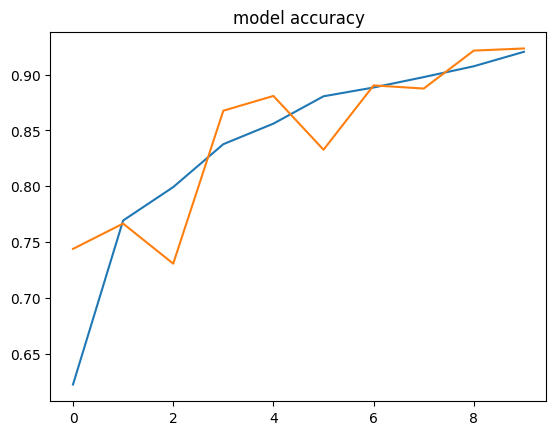

In [ ]:
import matplotlib.pyplot as plt

plt.plot(h['accuracy'])
plt.plot(h['val_accuracy'])

plt.title('model accuracy')
plt.show()

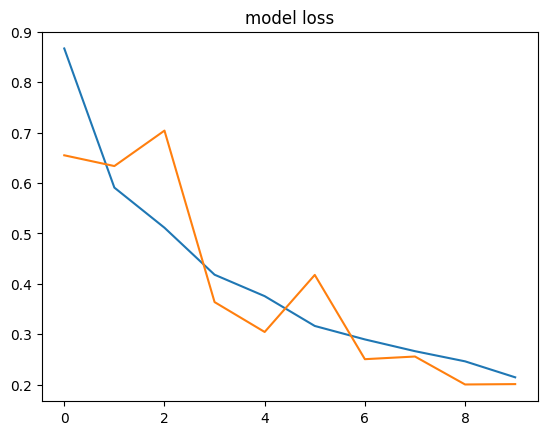

In [ ]:
import matplotlib.pyplot as plt

plt.plot(h['loss'])
plt.plot(h['val_loss'])

plt.title('model loss')
plt.show()

In [ ]:
#model accuracy

from keras.models import load_model
model = load_model('best_brain_model.keras')

In [ ]:
acc= model.evaluate(test_data)[1]
print(f"the accuracy of our model is {acc*100}%")

67/67 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.9209 - loss: 0.2358
the accuracy of our model is 92.09039807319641%


In [ ]:
from keras.preprocessing.image import load_img, img_to_array

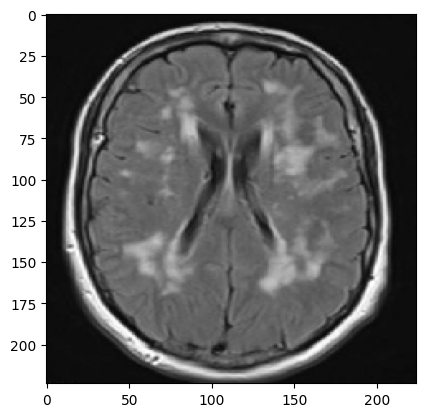

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted class index: 1
the mass is  healthy
Predicted probability: 1.0000


In [ ]:
import numpy as np
from keras.preprocessing.image import load_img, img_to_array

path = "/content/drive/MyDrive/brain_tumor_dataset/healthy/0173.jpg"
img = load_img(path, target_size=(224,224))
input_arr = img_to_array(img)/255
plt.imshow(input_arr)
plt.show()

input_arr.shape

input_arr = np.expand_dims(input_arr, axis=0)


# pred = model.predict_classes(input_arr)[0][0] # predict_classes is deprecated
predictions = model.predict(input_arr)
pred_class = np.argmax(predictions, axis=1)[0]
pred_prob = np.max(predictions, axis=1)[0]

print(f"Predicted class index: {pred_class}")
if pred_class == 0:
    print("The mass is A tumor and it's type is: Glioma")
if pred_class == 1:
    print("the mass is  healthy")
if pred_class == 2:
    print("The mass is A tumor and it's type is:  meningioma")
if pred_class == 3:
    print("The mass is A tumor and it's type is:  pituitary")
print(f"Predicted probability: {pred_prob:.4f}")



In [ ]:
train_data.class_indices

{'glioma': 0, 'healthy': 1, 'meningioma': 2, 'pituitary': 3}